**Yilin Pan, Daniel Lyu**

Spring 2026

CS 443: Bio-inspired Machine Learning

# Project 3: Word Embeddings and Self-Organizing Maps (SOMs)

#### Week 2: Visualizing word embeddings with Self-Organizing Maps

In [1]:
import os, sys, shutil

REPO_URL = "https://github.com/Athelas011/CS443-26SP.git"
REPO_DIR = "/content/CS443-26SP"
PROJECT_DIR = f"{REPO_DIR}/project3"

# IMPORTANT: move out of the repo before deleting it
os.chdir("/content")
%cd /content

# Delete old clone
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

# Clone fresh copy
!git clone {REPO_URL} {REPO_DIR}

# Move into project folder
os.chdir(PROJECT_DIR)
%cd {PROJECT_DIR}

# Fix import path
if PROJECT_DIR in sys.path:
    sys.path.remove(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

# Clear cached modules
for module_name in ["som", "text_util"]:
    sys.modules.pop(module_name, None)



/content
Cloning into '/content/CS443-26SP'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 198 (delta 26), reused 15 (delta 7), pack-reused 156 (from 1)
Receiving objects: 100% (198/198), 56.61 MiB | 15.20 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf


import som

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 3: Implement a Self-Organizing Map (SOM) neural network

You will implement a SOM to visualize the word embeddings in a 2D plot ("word cloud") and use the Iris dataset as a toy dataset to test your implementation.

**Note:** This neural network should be implemented using NumPy rather than TensorFlow. Because this network is not GPU accelerated, this week you might be able to run everything locally on your machine.

### 3a. Load and preprocess Iris

Preprocess the data in the following way to ultimately produce `iris_x` (training data) and `iris_y` (classes):
- Use all Iris features in the dataset except for "species". Normalize each row by its Euclidean distance so that the length of each data vector is 1.
- Convert to "species" column (classes) to an int-code (e.g. values take on 0, 1, 2). *Might be helpful to consult your Project 0 from CS343.*
- Make sure `iris_x` and `iris_y` are both ndarrays.

Run the following test code to double-check your preprocessing.

In [3]:
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# select data cols except for species
iris_data = iris.iloc[:, 0:4]
# normalize each row data vector
iris_data = iris_data.apply(lambda row: row/np.linalg.norm(row), axis=1)
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width
0,0.803773,0.551609,0.220644,0.031521
1,0.828133,0.507020,0.236609,0.033801
2,0.805333,0.548312,0.222752,0.034269
3,0.800030,0.539151,0.260879,0.034784
4,0.790965,0.569495,0.221470,0.031639


In [5]:
# convert dataframe to numpy array
iris_x = iris_data.to_numpy()

# recode species type str as ints
iris_y = iris['species']
iris_y = pd.Categorical(iris_y)
iris_y = iris_y.codes

#### Test Iris preprocessing

In [6]:
print(f'Number of samples are {iris_x.shape[0]} and classes are {len(iris_y)}.\nThey should both be 150.\n')
print(f'1st 2 rows of preprocessed iris:\n{iris_x[:2]}')
print('They should be:\n[[0.804 0.552 0.221 0.032]\n [0.828 0.507 0.237 0.034]]\n')
print(f'Your first 4 classes of iris:\n{iris_y[:4]} and they should be\n[0 0 0 0]')
print(f'Your last 4 classes of iris:\n{iris_y[-4:]} and they should be\n[2 2 2 2]')

Number of samples are 150 and classes are 150.
They should both be 150.

1st 2 rows of preprocessed iris:
[[0.804 0.552 0.221 0.032]
 [0.828 0.507 0.237 0.034]]
They should be:
[[0.804 0.552 0.221 0.032]
 [0.828 0.507 0.237 0.034]]

Your first 4 classes of iris:
[0 0 0 0] and they should be
[0 0 0 0]
Your last 4 classes of iris:
[2 2 2 2] and they should be
[2 2 2 2]


### 3b. Implement the SOM constructor

The main job here is to initialize the wts to random values.

Write test code below by creating a SOM (call it `iris_som`) in the cell below with the following characteristics:
- 3x3 grid size
- Set the number of features equal to the number of features in the iris training set.

In [7]:
iris_som= som.SOM(map_sz=(3, 3), num_feats=4)

# Keep this test code
test_wts = iris_som.get_wts()
print(f'Your SOM initial wt shape: {test_wts.shape}. It should be (3, 3, 4)')
print(f'Length of one of your wts: {np.sqrt(np.square(test_wts[1, 1]).sum()):.2f}. It should be 1.14')
print(f'Summed length of all of your wts: {np.sqrt(np.square(test_wts).sum(axis=2)).sum():.4}. It should be 10.58.')

Your SOM initial wt shape: (3, 3, 4). It should be (3, 3, 4)
Length of one of your wts: 1.14. It should be 1.14
Summed length of all of your wts: 10.58. It should be 10.58.


### 3c. Get the SOM best matching unit for the 1st Iris sample

Implement `get_bmu` to get the **best matching unit (BMU)** to a data sample. Recall: the BMU is the SOM neuron with the closest wts to the current data sample, measured by Euclidean distance.

**Notes**:
- In core SOM functions like this, you should not use loops of any kind. Your training code will be frustratingly slow if you use loops. Check out the method docstring to see whether loops are discouraged. *This is something that you could quantify as an extension.*
- If vectorization is taking too much time to figure out, start with for loops and revisit this later.

#### Test `get_bmu`

In the cell below, add two calls to the function to get the BMU for the FIRST and LAST Iris samples. This isn't meaningful yet because we have not trained the SOM yet.

*Keep the code that replaces the wts in your SOM — this is for testing purposes, just to ensure that everyone's test code matches despite how you generate your SOM wts.*

In [8]:
# Add your code to get the BMU for the 1st iris sample here
bmu1 = iris_som.get_bmu(iris_x[0])
print(f'BMU for Iris sample 1 is at {bmu1} and should be at (0, 0).')

# Add your code to get the BMU for the last iris sample here
bmu2 = iris_som.get_bmu(iris_x[-1])
print(f'BMU for Iris sample 150 is at {bmu2} and should be at (2, 1).')

BMU for Iris sample 1 is at (0, 0) and should be at (0, 0).
BMU for Iris sample 150 is at (2, 1) and should be at (2, 1).


### 3d. Find the nearest SOM wt vector to each current data sample

Implement and test `get_nearest_wts` to "automate" the process of finding the closest wts to EVERY data sample in the dataset. In this case, return the set of closest wts rather than the indices of the SOM neurons.

In [9]:
print(f'The nearest wt vec to 1st Iris sample {iris_x[0]} is\n{iris_som.get_nearest_wts(iris_x)[0]} and should be')
print('[0.637 0.27  0.041 0.017]')
print(f'The nearest wt vec to last Iris sample {iris_x[-1]} is\n{iris_som.get_nearest_wts(iris_x)[-1]} and should be')
print('[0.686 0.65  0.688 0.389]')

The nearest wt vec to 1st Iris sample [0.804 0.552 0.221 0.032] is
[0.637 0.27  0.041 0.017] and should be
[0.637 0.27  0.041 0.017]
The nearest wt vec to last Iris sample [0.69  0.351 0.597 0.211] is
[0.686 0.65  0.688 0.389] and should be
[0.686 0.65  0.688 0.389]


### 3e. Define the Gaussian neighborhood

Once we know the BMU for a particular data sample, we want to not only update the BMU's wts, but also the wts of its neighbors in the SOM grid (albeit to a weaker extent). Before we can update the BMU's wts, we need to be able to determine the Gaussian neighborhood surrounding the BMU. This is achieved by the function `gaussian`.

Implement and test `gaussian` below.

##### Test 1

In [10]:
cent_rc = (1, 1)
sigma = 1.0
print(iris_som.gaussian(cent_rc, sigma))
print('The Test 1 Gaussian neighborhood should look like:')
print('''[[0.368 0.607 0.368]
 [0.607 1.    0.607]
 [0.368 0.607 0.368]]''')

[[0.368 0.607 0.368]
 [0.607 1.    0.607]
 [0.368 0.607 0.368]]
The Test 1 Gaussian neighborhood should look like:
[[0.368 0.607 0.368]
 [0.607 1.    0.607]
 [0.368 0.607 0.368]]


##### Test 2

In [11]:
cent_rc = (0, 1)
print(iris_som.gaussian(cent_rc, sigma))
print('The Test 2 Gaussian neighborhood should look like:')
print('''[[0.607 1.    0.607]
 [0.368 0.607 0.368]
 [0.082 0.135 0.082]]''')

[[0.607 1.    0.607]
 [0.368 0.607 0.368]
 [0.082 0.135 0.082]]
The Test 2 Gaussian neighborhood should look like:
[[0.607 1.    0.607]
 [0.368 0.607 0.368]
 [0.082 0.135 0.082]]


##### Test 3

In [12]:
cent_rc = (0, 1)
sigma = 0.5
print(iris_som.gaussian(cent_rc, sigma))
print('The Test 3 Gaussian neighborhood should look like:')
print('''[[0.135 1.    0.135]
 [0.018 0.135 0.018]
 [0.    0.    0.   ]]''')

[[0.135 1.    0.135]
 [0.018 0.135 0.018]
 [0.    0.    0.   ]]
The Test 3 Gaussian neighborhood should look like:
[[0.135 1.    0.135]
 [0.018 0.135 0.018]
 [0.    0.    0.   ]]


### 3f. Update BMU wts

Implement `update_wts` to bring the wts of the BMU and its neighbors closer to the current data sample. The SOM update rule is

$$\vec{w_{rc}}(t) = \vec{w_{rc}}(t-1) + \alpha g_{r_{bmu}, c_{bmu}}(r, c)\left ( \vec{x_i} - \vec{w_{rc}}(t-1)\right )$$

Above, $w_{rc}$ is the SOM weight vector belonging to the unit positioned at row $r$ and column $c$, $t$ is iteration number, $g_{r_{bmu}, c_{bmu}}(r, c)$ is the Gaussian neighborhood matrix centered on the BMU evaluated at the SOM $(row, col) = (r, c)$, $x_i$ is the data vector, and $\alpha$ is the learning rate.

**Note:** This weight update occurs to ALL SOM unit rows and columns $(r, c)$ because of the Gaussian neighborhood function.

#### Test `update_wts`

In the cell below, call the wt update method on the FIRST Iris sample, plugging in the row/column of the BMU determined above (*before the Gaussian tests*), and a learning rate of `0.1` and Gaussian sigma of `1.0`.

In [13]:
# Keep the following test code
rng = np.random.default_rng(0)
iris_som.wts = rng.uniform(0, 1, iris_som.wts.shape)

# Write your code here

# Keep the following test code
test_wts = iris_som.get_wts()
print('Your SOM wts after updating the wts based on the 1st Iris sample are:')
print(test_wts)
print('\nThe output should be:')
print('''[[[0.647 0.287 0.052 0.017]
  [0.813 0.899 0.592 0.704]
  [0.546 0.932 0.811 0.003]]

 [[0.852 0.085 0.679 0.161]
  [0.86  0.542 0.295 0.399]
  [0.039 0.13  0.665 0.639]]

 [[0.627 0.394 0.95  0.923]
  [0.69  0.647 0.671 0.376]
  [0.141 0.72  0.523 0.308]]]''')

Your SOM wts after updating the wts based on the 1st Iris sample are:
[[[0.637 0.27  0.041 0.017]
  [0.813 0.913 0.607 0.729]
  [0.544 0.935 0.816 0.003]]

 [[0.857 0.034 0.73  0.176]
  [0.863 0.541 0.3   0.423]
  [0.028 0.124 0.671 0.647]]

 [[0.615 0.384 0.997 0.981]
  [0.686 0.65  0.688 0.389]
  [0.135 0.721 0.525 0.31 ]]]

The output should be:
[[[0.647 0.287 0.052 0.017]
  [0.813 0.899 0.592 0.704]
  [0.546 0.932 0.811 0.003]]

 [[0.852 0.085 0.679 0.161]
  [0.86  0.542 0.295 0.399]
  [0.039 0.13  0.665 0.639]]

 [[0.627 0.394 0.95  0.923]
  [0.69  0.647 0.671 0.376]
  [0.141 0.72  0.523 0.308]]]


### 3g. Hyperparameter decay

The last thing that needs to happen before we can train on multiple samples is to decay the network's hyperparameters (learning rate and neighborhood sigma). Implement exponential weight decay using the formula: $$p(t) = p(0) \exp \left(-t/\tau \right)$$ where $p(0)$ is the initial hyperparameter value at the start of training, $t$ is the current iteration number. The variable $\tau$ is the decay constant defined as: $$\tau = -(\text{NIter}-1) / \log \left (\frac{p(0)}{p(\text{NIter})} \right) $$

where $\text{NIter}$ is the total number of training iterations and $p(\text{final})$ is the desired hyperparameter value at the end of training.

In the cell below, write a loop that decays a parameter from an initial value of 1.5 to a final value of 0.5 over 10 iterations.

`1.5000 1.3276 1.1751 1.0400 0.9205 0.8147 0.7211 0.6383 0.5649 0.5000`

In [14]:
initial_val = 1.5
final_val = 0.5
num_iters = 10

for curr_iter in range(num_iters):
    val = iris_som.decay_param(curr_iter, num_iters, initial_val, final_val)
    print(f"{val:.4f}", end=" ")

1.5000 1.3276 1.1751 1.0400 0.9205 0.8147 0.7211 0.6383 0.5649 0.5000 

### 3h. Train SOM on Iris

Implement the `fit` method to train a SOM for some number of epochs.

Write code below that recreates the SOM that you've been working with above. Use the default hyperparameters except:
- Train for `10` epochs.
- initial learning rate of `2.0` and sigma of `9.0`.

Signs that your code is working:
- it takes no longer than a second or two to run.
- you get 10 print outs (1 per epoch) showing the learning rate and sigma.
- both the learning rate and sigma decrease substantially across epochs.
- your learning rate after 10 epochs should be `0.01`.
- your sigma after 10 epochs should be `0.01`.

In [15]:
# Keep the code below
iris_x_cpy = iris_x.copy()

iris_som = som.SOM((3, 3), 4)

# Your code here
iris_som.fit(iris_x_cpy, epochs = 10, lr_initial=2.0, lr_final=0.01, sigma_initial=0.9, sigma_final=0.01, print_every=1,
            seed=0, verbose=True)
# Keep the below code for testing
if not np.allclose(iris_x, iris_x_cpy):
    print('Uh oh, you changed the original training data, which is not good.')

Starting training for 10 epochs...
Epoch 1/10 | LR: 1.1812 | Sigma: 0.5754 | BMU Error: 0.0521
Epoch 2/10 | LR: 0.6951 | Sigma: 0.3668 | BMU Error: 0.0379
Epoch 3/10 | LR: 0.4091 | Sigma: 0.2338 | BMU Error: 0.0335
Epoch 4/10 | LR: 0.2407 | Sigma: 0.1490 | BMU Error: 0.0339
Epoch 5/10 | LR: 0.1417 | Sigma: 0.0950 | BMU Error: 0.0326
Epoch 6/10 | LR: 0.0834 | Sigma: 0.0606 | BMU Error: 0.0323
Epoch 7/10 | LR: 0.0491 | Sigma: 0.0386 | BMU Error: 0.0320
Epoch 8/10 | LR: 0.0289 | Sigma: 0.0246 | BMU Error: 0.0321
Epoch 9/10 | LR: 0.0170 | Sigma: 0.0157 | BMU Error: 0.0321
Epoch 10/10 | LR: 0.0100 | Sigma: 0.0100 | BMU Error: 0.0321
Finished training.


### 3i. Assessing performance with quantization error

How well did you do at learning the structure of Iris?

One way to answer this question is to compute the **BMU quantization error** (BMU error for short): On average, how much error do we incur by approximating each data sample by the weights of the corresponding BMU in the network?

#### Todo

- Implement the `error` method to determine the BMU error.
- Go back to `fit` and when you print out training progress, print out the BMU error evaluated on the entire training set. If everything goes well, in the above fit test run with Iris, your BMU error should decrease substantially over the 10 epochs to ≤0.05 (*There may be the occasional increase, but it should decrease on average over the 10 epochs*).

### 3j. Visualize the learned structure of Iris by SOM

One main advantage of using SOM is the ability to visualize the structure of high dimensional data in 2D. A trained SOM can be visualized by computing its **U-matrix**: the average distance between each neuron's weights and its 8 neighbors.

Implement `u_matrix` so that you can visualize your network's representation of the Iris data.

#### Test `u_matrix`

In the cell below, do the following to visualize the learned representation of Iris across the SOM grid of neurons.
1. Train a 70x70 SOM on Iris for 4 epochs. Use an initial learning rate of `1.0` and sigma of `45.0`. This should complete in at most several seconds.
2. Compute the U-matrix and plot it as a grayscale image/heatmap. Add a colorbar (*values should range 0 to 1)*).
3. Superimpose plot markers corresponding to each Iris sample (i.e. there should be 150 of them). Do this by determining the BMU of each data sample in the trained SOM, then drawing a plot marker at the BMU position. Color each marker according to the sample's true class.

If all goes well, your U-matrix superimposed with the most active units for each training sample should (roughly) look like the lower-right image on [Wikipedia](https://en.wikipedia.org/wiki/File:SOM_of_Fishers_Iris_flower_data_set.JPG).

Starting training for 4 epochs...
Epoch 1/4 | LR: 0.3181 | Sigma: 5.5524 | BMU Error: 0.0179
Epoch 2/4 | LR: 0.1004 | Sigma: 0.6755 | BMU Error: 0.0125
Epoch 3/4 | LR: 0.0317 | Sigma: 0.0822 | BMU Error: 0.0115
Epoch 4/4 | LR: 0.0100 | Sigma: 0.0100 | BMU Error: 0.0112
Finished training.


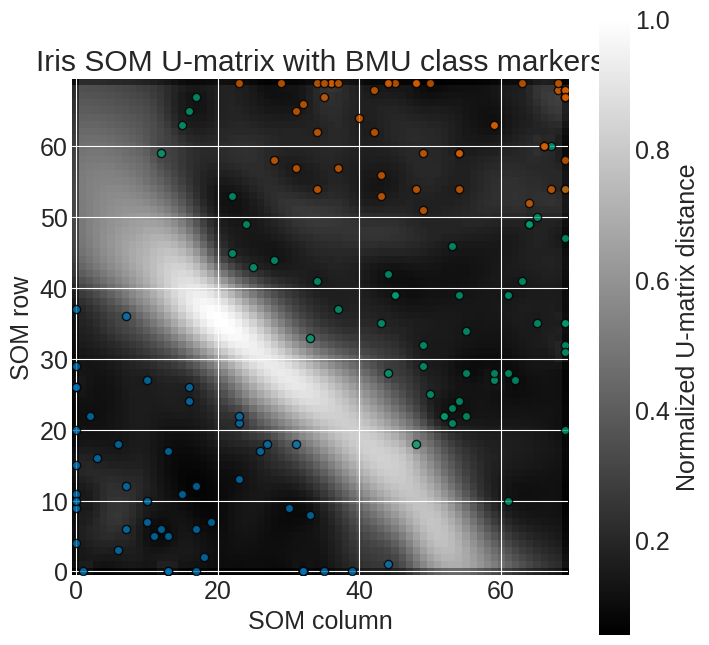

In [16]:
iris_som = som.SOM((70,70), 4)
iris_som.fit(iris_x, epochs = 4, lr_initial=1.0, lr_final=0.01, sigma_initial=45, sigma_final=0.01, print_every=1,
            seed=0, verbose=True)

u_mat = iris_som.u_matrix()

plt.figure(figsize=(8, 8))
plt.imshow(u_mat, cmap="gray", origin="lower")
plt.colorbar(label="Normalized U-matrix distance")


for i in range(iris_x.shape[0]):
    sample = iris_x[i]
    label = iris_y[i]

    bmu_row,bmu_col = iris_som.get_bmu(sample)

    plt.scatter(
        bmu_col,
        bmu_row,
        c=f"C{label}",
        marker="o",
        edgecolors="black",
        s=35,
        alpha=0.8
    )

plt.title("Iris SOM U-matrix with BMU class markers")
plt.xlabel("SOM column")
plt.ylabel("SOM row")
plt.show()

### 3k. Questions

**Question 1**: Explain what the above visualization is showing us. Why does the plot look different than Iris scatter plots like you're used to seeing?

**Question 2**: Copy the plot with default hyperparameters into a separate cell (or save it in your project folder). How do the following affect the structure of the U-matrix?
- Number of epochs
- learning rate
- Gaussian neighborhood sigma
- SOM grid size

**Question 3**: Change the random seed used for initializing the weights. Does it matter that the clusters may jump around? **Explain why**.

**Question 4**: What does the dark band mean? What does it tell us about the data?

**Answer 1**: The U-matrix shows the average Euclidean distance between each SOM neuron's weights and its neighbors — dark regions indicate neurons with similar weights (cluster interiors) and light regions indicate large differences (cluster boundaries). It looks different from a standard Iris scatter plot because the axes are SOM grid coordinates, not original feature dimensions; position reflects learned topological similarity rather than raw feature values.

**Answer 2**:
- **Epochs**: More epochs → sharper, more defined boundaries; too few → blurry, poorly separated regions.
- **Learning rate**: Higher initial LR → faster but coarser organization; lower → finer structure but slower convergence.
- **Sigma**: Larger sigma → broader, smoother clusters (global structure); smaller sigma → tighter, more localized clusters (local structure).
- **Grid size**: Larger grid → finer-grained sub-clusters; smaller grid → coarser, fewer distinguishable regions.

**Answer 3**: No. The SOM is topology-preserving, so the relative structure (which samples cluster together and how clusters relate to each other) is the same regardless of initialization. Only the *position* of clusters on the grid changes with different seeds, not the underlying groupings they represent.

**Answer 4**: A dark band indicates a sharp boundary between two groups of neurons with very different weight vectors — i.e., a gap between two well-separated clusters in the data. For Iris, it means at least two species occupy clearly distinct, non-overlapping regions of feature space.

## Task 4: Visualize IMDb word embeddings as a word cloud

In [17]:
from text_util import get_most_similar_words, find_unique_word_counts

### 4a. Load word embedding vectors

1. Run the cell below to load the Skip-gram word embeddings and the associated word strings.
2. Min-max normalize your word vectors, treating them as your "dataset" (i.e. normalize per-feature across samples).

In [18]:
embedding_dict = np.load('export/embeddings.npz')
word_vectors = embedding_dict['embeddings']

with open('export/corpus.pkl', 'rb') as fp:
    corpus = pickle.load(fp)

with open('export/vocab.pkl', 'rb') as fp:
    vocab = pickle.load(fp)

with open('export/word2ind_map.pkl', 'rb') as fp:
    word2ind = pickle.load(fp)

with open('export/ind2word_map.pkl', 'rb') as fp:
    ind2word = pickle.load(fp)

print(f'Loaded {len(word_vectors)} word embedding vectors and {len(vocab)} words.')

# TODO: min-max normalize the word vectors
mins = word_vectors.min(axis=0)
maxs = word_vectors.max(axis=0)

word_vectors_norm = (word_vectors - mins) / (maxs - mins + 1e-10)

Loaded 58311 word embedding vectors and 58311 words.


### 4b. Getting top-k most similar words to a query word

Given how many words the IMDb dataset is, it will be challenging to read all the words when we plot them in our SOM word cloud. To assist with this, let's use the **cosine similarity** to determine the top-k most similar words (based on the word vectors) then highlight those in the plot to see the degree to which the similar words actually appear nearby your query word in the SOM.

In `text_util.py`, implement the `get_most_similar_words(k, word_str, all_embeddings, word_str2int, eps=1e-10)` function that returns the top-`k` most similar words to the query word `word_str`.

Here is a refresher on the cosine similarity equation:

$$
\text{Cosine Similarity} = \frac{(\text{Wts})(\vec{w})}{\sqrt{\sum_{j=1}^H (\text{Wts}^T)_j^2} \sqrt{\sum_{j=1}^H w_j^2}}
$$

where $\text{Wts}$ are all the embeddings, $\text{Wts}^T$ is the transpose of the embeddings, $\vec{w}$ is the word embedding vector for the query word.

The test code below should print:

```
0: Waterville (similarity=1.0000)
1: Bangor (similarity=0.9687)
2: Camden (similarity=0.9560)
3: Portland (similarity=0.9453)
```

In [19]:
test_word_str2int = {
                     'Waterville': 0,
                     'Acadia': 1,
                     'Camden': 2,
                     'Portland': 3,
                     'Boothbay': 4,
                     'Bangor': 5,
                     'Kennebunkport': 6
                    }
test_word_int2str = {
                     0: 'Waterville',
                     1: 'Acadia',
                     2: 'Camden',
                     3: 'Portland',
                     4: 'Boothbay',
                     5: 'Bangor',
                     6: 'Kennebunkport'
                    }

test_word_str = 'Waterville'
tf.random.set_seed(0)
test_embeddings = tf.random.uniform(shape=(7, 4)).numpy()
test_top_inds, test_top_sims = get_most_similar_words(k=3,
                                                      all_embeddings=test_embeddings,
                                                      word_str=test_word_str,
                                                      word_str2int=test_word_str2int)

print(f'Words most similar to {test_word_str}:')
for k0 in range(len(test_top_inds)):
    print(f'{k0}: {test_word_int2str[test_top_inds[k0]]} (similarity={test_top_sims[k0]:.4f})')

Words most similar to Waterville:
0: Waterville (similarity=1.0000)
1: Bangor (similarity=0.9687)
2: Camden (similarity=0.9560)
3: Portland (similarity=0.9453)


### 4c. Train SOM on word embedding vectors

Below, train a new SOM on the word vectors. Training should take some time. Use default hyperparameters except for:
- `50x50` size
- `10` training epochs
- Initial learning rate of `0.5` with a decay rate of 0.9999.
- Initial Gaussian neighborhood standard deviation of `25.0`. Final value of `1.0`.

After training, create a grayscale heatmap of the U-matrix with a colorbar like you did for Iris (don't superimpose the data samples). You want to check and make sure that the U-matrix has *structure* to it (not look like random salt-and-pepper/"static looking" pixel noise or be completely black/white/gray).

**Notes:**
- You are encouraged to experiment with the hyperparameters, the above values are starting points. *A more detailed investigation could be an extension.*
- Training can be much, much slower if you have used for loops in the core algorithm (methods called on every iteration of SGD). If you're unable to do this, reduce the SOM grid size and/or number of training epochs, but be aware that your results may not be as good.
- Just like the simpler Iris test, you should see your BMU decrease over epochs.

Starting training for 4 epochs...
Epoch 1/4 | LR: 0.0015 | Sigma: 3.5356 | BMU Error: 0.6063
Epoch 2/4 | LR: 0.0000 | Sigma: 0.5000 | BMU Error: 0.6037
Epoch 3/4 | LR: 0.0000 | Sigma: 0.0707 | BMU Error: 0.6037
Epoch 4/4 | LR: 0.0000 | Sigma: 0.0100 | BMU Error: 0.6037
Finished training.


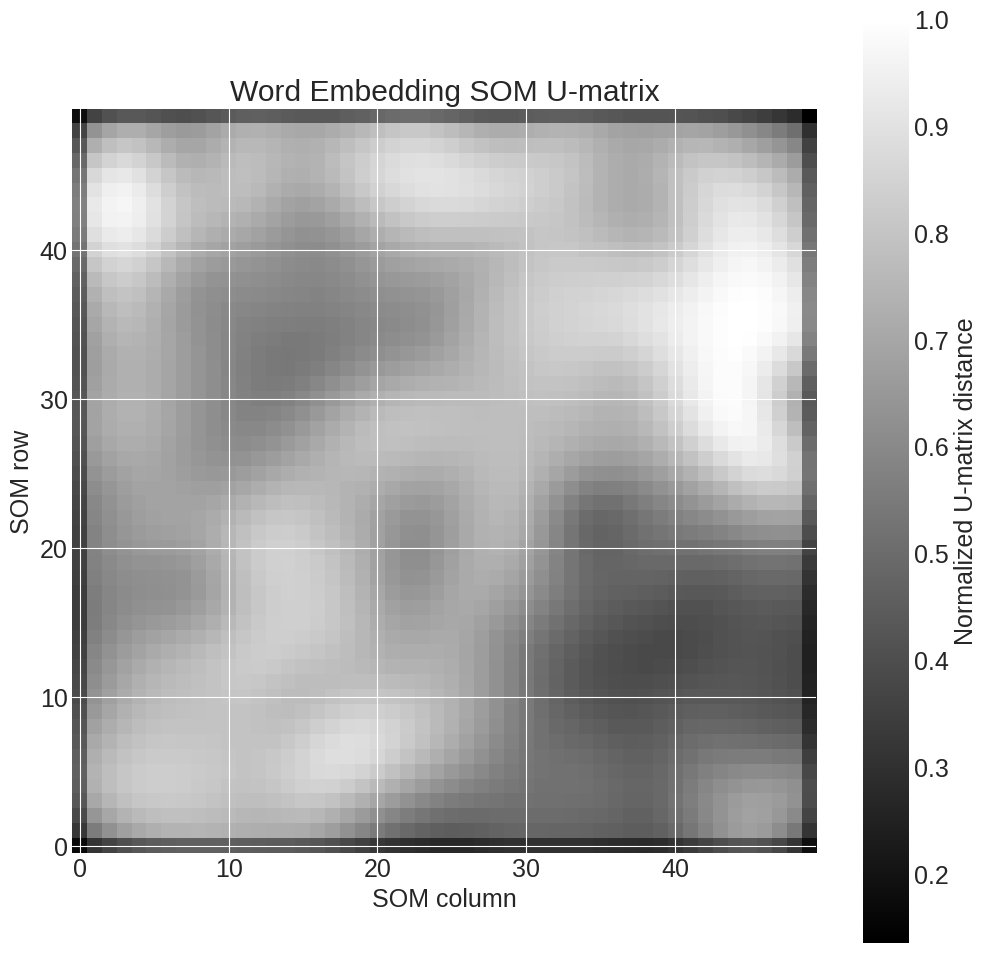

In [20]:
word_som = som.SOM(map_sz=(50,50), num_feats=word_vectors_norm.shape[1])
epochs = 4
lr_initial = 0.5
lr_decay = 0.9999
num_iters = epochs * len(word_vectors_norm)

lr_final = lr_initial * (lr_decay ** (num_iters - 1))

word_som.fit(
    word_vectors_norm,
    epochs=epochs,
    lr_initial=lr_initial,
    lr_final=lr_final,
    sigma_initial=25,
    sigma_final=0.01,
    print_every=1,
    seed=0,
    verbose=True
)


u_mat = word_som.u_matrix()

plt.figure(figsize=(12, 12))
plt.imshow(u_mat, cmap="gray", origin="lower")
plt.colorbar(label="Normalized U-matrix distance")

plt.title("Word Embedding SOM U-matrix")
plt.xlabel("SOM column")
plt.ylabel("SOM row")
plt.show()

### 4d. Produce IMDb review word cloud

Pick a word for `query_word` (has it be in the vocab) and run the cell below to show the words with the 25 most similar embeddings as well as a scatter plot, which shows all the word embeddings but annotates the query word and the most similar words.

**Note:** If it's helpful, there is code in the last cell of this section that prints of the top-k most common words in the corpus to help you identity words in the vocab.

In [30]:
# TODO: Pick a query word

query_word = 'movie'

topk_word_inds, topk_cossim = get_most_similar_words(k=25,
                                                     all_embeddings=word_vectors,
                                                     word_str=query_word,
                                                     word_str2int=word2ind)


word_strs = [ind2word[ind] for ind in topk_word_inds]

print(f'Words most similar to {query_word}:')
for k0 in range(len(topk_word_inds)):
    print(f'{k0}: {ind2word[topk_word_inds[k0]]} (similarity={topk_cossim[k0]:.4f})')

Words most similar to movie:
0: movie (similarity=1.0000)
1: film (similarity=0.8824)
2: flick (similarity=0.6703)
3: documentary (similarity=0.6482)
4: show (similarity=0.5859)
5: episode (similarity=0.5743)
6: sequel (similarity=0.5738)
7: movies (similarity=0.5655)
8: programme (similarity=0.5293)
9: it (similarity=0.5250)
10: series (similarity=0.5134)
11: thriller (similarity=0.4988)
12: picture (similarity=0.4913)
13: debacle (similarity=0.4876)
14: thing (similarity=0.4796)
15: anime (similarity=0.4738)
16: gem (similarity=0.4726)
17: pic (similarity=0.4702)
18: franchise (similarity=0.4691)
19: films (similarity=0.4665)
20: 'starship (similarity=0.4663)
21: mini (similarity=0.4653)
22: trailer (similarity=0.4607)
23: abomination (similarity=0.4591)
24: entry (similarity=0.4571)
25: dribble (similarity=0.4569)


Run the following code to generate the word cloud. This is similar to what you did for Iris, except rather than showing colored plot markers, we are displaying the word at the position of its BMU in the SOM grid.

Feel free to adjust the number of words visualized, font size, and the random offset of each BMU to help reduce words being plotted on top of each other.

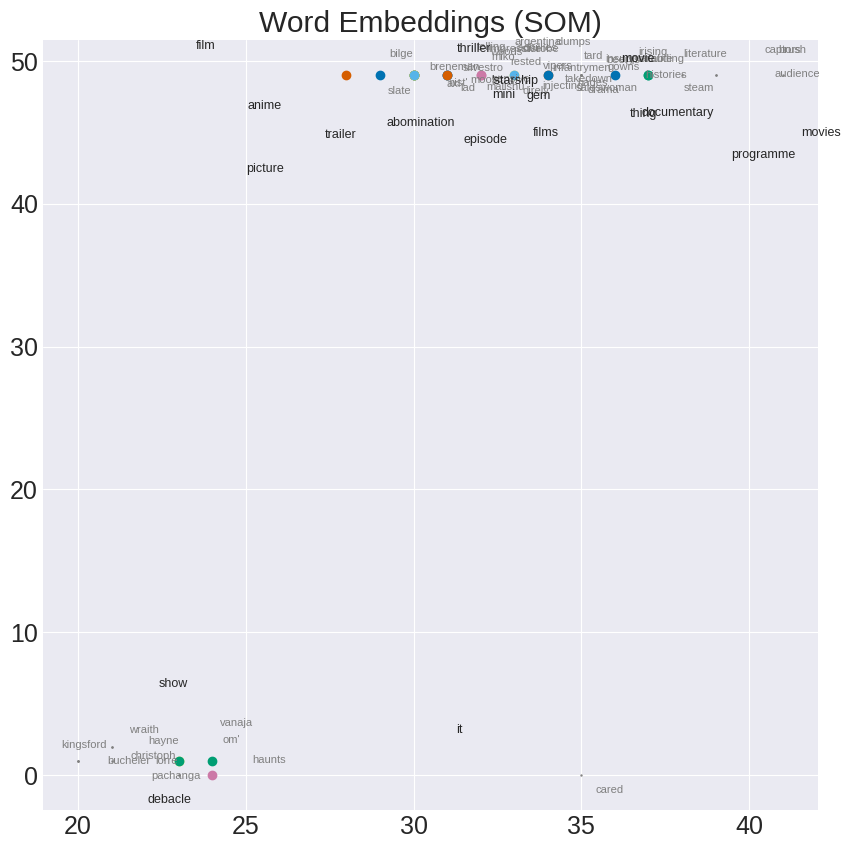

In [31]:
# Visualize a random subset of word embeddings for speed
num_words_to_visualize = 50
rng_vis = np.random.default_rng()
word_inds = rng_vis.choice(len(word_vectors), size=num_words_to_visualize, replace=False)

label_background_jitter = 2
label_closest_jitter = 8
jitter_xy = rng_vis.uniform(low=-label_background_jitter, high=label_background_jitter, size=(num_words_to_visualize, 2))

# Visualize word cloud — each word as (x, y) coords
fig, ax = plt.subplots(figsize=(10, 10))
for i, w_ind in enumerate(word_inds):
    bmu_pos = word_som.get_bmu(word_vectors[w_ind])
    x_jit = bmu_pos[0] + 0.5 + jitter_xy[i, 0]
    y_jit = bmu_pos[1] + 0.5 + jitter_xy[i, 1]
    ax.scatter(bmu_pos[0], bmu_pos[1], s=0.5, c='gray')
    ax.annotate(vocab[w_ind], (x_jit, y_jit), fontsize=8, color='gray')

jitter_xy = rng_vis.uniform(low=-label_closest_jitter, high=label_closest_jitter, size=(len(topk_word_inds), 2))

# Make sure we definitely plot the closest words to the query and annotate with word str
for i, w_ind in enumerate(topk_word_inds):
    bmu_pos = word_som.get_bmu(word_vectors[w_ind])
    ax.scatter(bmu_pos[0], bmu_pos[1])
    # Show the label offset for readability
    x_jit = bmu_pos[0] + 0.5 + jitter_xy[i, 0]
    y_jit = bmu_pos[1] + 0.5 + jitter_xy[i, 1]
    ax.annotate(vocab[w_ind], (x_jit, y_jit), fontsize=9)

plt.title('Word Embeddings (SOM)')
plt.show()

### 4d. Questions

**Question 5:** What are your favorite word clusters?

**Question 6:**

(a) Are there any word groupings that surprised you (but make sense post-hoc)?

(b) Are there words that you think should go together but are not?

**Answer 5:** movie

**Answer 6:**
(a) People's name grouping doesn't make a lot of sense to me (more like random words)

(b) film is from from show

In [32]:
# TODO: Modify variable name `corpus` to refer to your IMDb corpus
unique_word_counts = find_unique_word_counts(corpus=corpus)
top_k = 200

print(f'Top {top_k} words (by count in corpus):')
i = 0
for word, count in unique_word_counts.items():
    print(word, count)
    i += 1

    if i > top_k:
        break

Top 200 words (by count in corpus):
the 133569
and 64846
a 64458
of 57823
to 53328
is 42554
in 37342
it 31369
i 30501
this 30178
that 27294
was 19004
as 18237
movie 17573
with 17532
for 17461
but 16680
film 15264
on 13727
you 12125
not 11983
are 11608
his 11318
have 11080
be 10678
one 10485
he 10262
its 9964
all 9387
at 9248
by 8770
an 8548
they 8420
so 8224
who 8189
from 8120
like 8097
or 7236
just 7183
her 7113
about 6841
out 6800
if 6716
has 6512
there 6335
what 6198
some 6143
good 5971
when 5638
more 5538
very 5503
up 5271
no 5121
would 5001
even 4972
time 4954
my 4947
she 4887
which 4726
story 4584
their 4561
see 4539
only 4485
really 4444
were 4427
had 4363
can 4298
well 4284
me 4185
than 3923
much 3838
get 3746
been 3727
we 3701
bad 3665
because 3648
will 3644
great 3638
other 3635
into 3613
do 3584
first 3556
people 3498
also 3491
how 3485
most 3474
him 3401
dont 3361
made 3280
them 3226
movies 3225
make 3190
way 3174
then 3157
films 3082
too 3072
any 3005
could 2923
after 2921

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.**
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric).
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 1. SOM quantization error

Do an analysis (make plots, explain findings) where you investigate how various Skipgram and/or SOM parameters affect the quantization error (and clustering of words in the SOM). Parameters you might experiment with are:
- Number of epochs (Skip-gram and/or SOM)
- SOM size
- Learning rate (and its decay rate)
- Gaussian sigma (and its decay rate)
- Number of reviews used to train Skip-gram
- Context word window size.

**NOTE:** Some parameters may need to adjusted together in some fashion. For example, decreasing the SOM size decreases the grid size. Therefore, the Gaussian neighborhood size $\sigma$ probably needs to be rescaled, as does the learning rate (how much vectors move around in the space duing each update).

#### 2. More sophisticated text preprocessing

To preprocess text for Skipgram, we defined words as strings with at least one letter. Research and examine whether more sophisticated approaches (e.g. removing stop words, destemming, lemmatization, etc) to preprocessing text yield better word embedding results (better quality word context predictions, better word similiarity as represented by the SOM).

#### 3. Skip-gram word context

We only used the Skip-gram network to extract the word embedding vectors. Load in the IMDb test set, preprocess it, and explore how a trained Skip-gram network can predict words surrounding each target word.

#### 4. Continuous Bag of Words (CBOW)

In addition to Skip-gram, Mikolov et al. also proposed the CBOW model. Duplicate your Skipgram code and make the necessary modifications to implement CBOW. CBOW has the same overall architecture to Skip-gram, but the target and context words exchange roles in CBOW. In CBOW:
- Context words serve as the data samples.
- Target words (one-hot coded) serve as the classes.

Thus, the CBOW network is trained to "fill in the blank" given the context words.

- How do the word vectors compare to Skipgram?
- Analyze the target word predictions.

#### 5. Quality of SOM word clusters

Experiment with how SOM learning parameters and Skip-gram training time (and other parameters like # embedding dimensions, context window size) affect the quality of similar word cluster.

#### 6. Other text datasets

Obtain, load, and preprocess other text datasets. Train Skip-gram, visualize the word vectors using SOM, and interpret what you find.

#### 7. Supervised learning with Learning Vector Quantization (LVQ)

The SOM algorithm is closely related to LVQ, which can be applied to supervised learning problems. Create a child class of SOM that implements the LVQ algorithm and analyze its behavior when applied to a supervised learning dataset. There are numerous variants of LVQ (e.g. LVQ2, LVQ2.1, LVQ3, etc.). **Note:** Initialize the weights by randomly selecting samples in the dataset.

#### 8. Dimensionality reduction via SOM vs PCA

Do a comparison between the dimensionality reduction offered by SOM vs PCA.

#### 9. Dimensionality reduction and visualization of non-text datasets

SOM can be used to visualize and analyze the structure of high dimensional, non-text datasets. Find such datasets and apply SOM on them then analyze/interpret the structure.

#### 10. Implement mini-batch support or the batch SOM weight update rule

Follow the strategy outlined in the notes for adding mini-batch or full batch support. Both approaches should improve the speed of training so it would be interesting to compare the runtime and other performance characteristics between the "SGD-style" and mini-batch and/or batch approaches.

You could try a TensorFlow/GPU accelerated version and if you are successive, profile/analyze the runtime differences.

#### 11. Initialize SOM weights with first two principal component vectors

Follow the strategy outlined in class and the notes for PCA-based weight initialization. Compare the number of epochs necessary to train SOM effectively and analyze error and other characteristics.

#### 12. Negative sampling and Skipgram loss

We used a fixed number of negative samples when training Skipgram on the IMDb dataset. Is the value we selected a good value? Does the number of negative samples matter? Are negative samples really needed — does the network train any better than a simpler Skipgram network with *only* positive samples (i.e. uses standard softmax + cross entropy loss)?